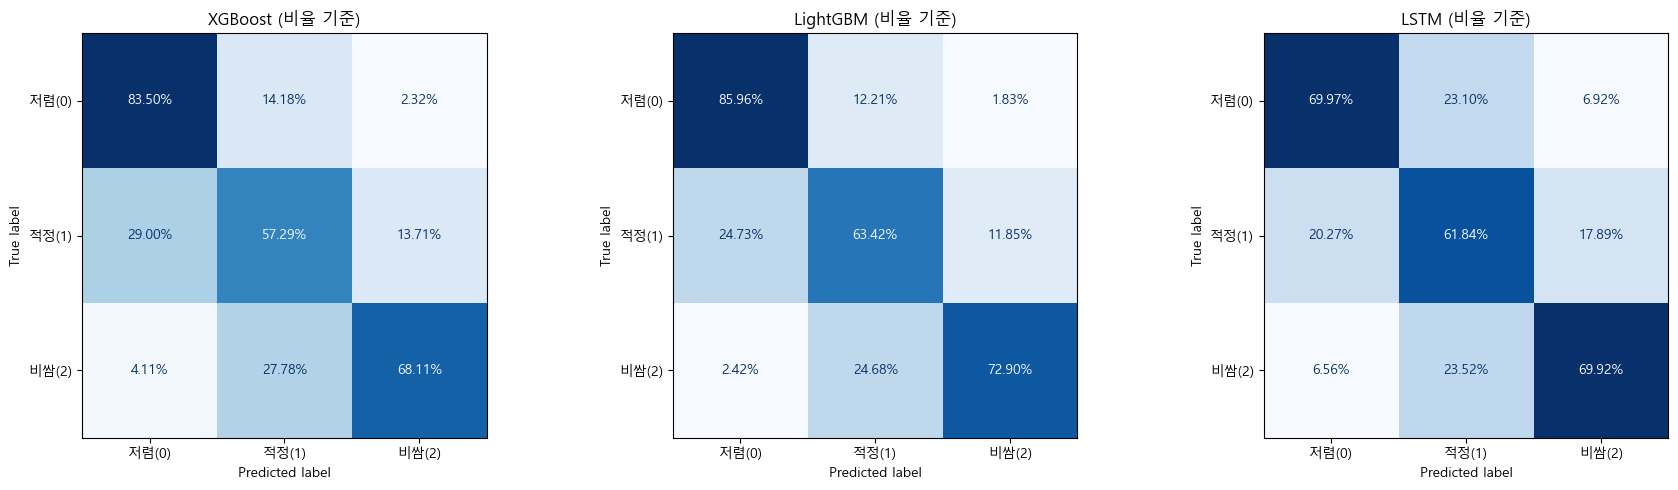

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# =========================
# 한글 폰트 설정 (Windows 기준)
# =========================
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 클래스 라벨
# =========================
labels = ["저렴(0)", "적정(1)", "비쌈(2)"]

# =========================
# Confusion Matrix 데이터
# =========================
cm_xgb = np.array([
    [11895, 2020,  331],
    [ 4691, 9266, 2217],
    [  897, 6060,14859]
])

cm_lgbm = np.array([
    [12246, 1739,  261],
    [ 4000,10258, 1916],
    [  528, 5384,15904]
])

cm_lstm = np.array([
    [17738, 5857, 1755],
    [ 4588,14001, 4050],
    [ 1352, 4848,14414]
])

# =========================
# 행 기준 정규화 (비율)
# =========================
def normalize_cm(cm):
    return cm / cm.sum(axis=1, keepdims=True)

cms = [
    normalize_cm(cm_xgb),
    normalize_cm(cm_lgbm),
    normalize_cm(cm_lstm)
]

titles = ["XGBoost", "LightGBM", "LSTM"]

# =========================
# 시각화
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(axes, cms, titles):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format=".2%",   # ✅ 비율(%) 표시
        colorbar=False
    )
    ax.set_title(f"{title} (비율 기준)")

plt.tight_layout()
plt.show()


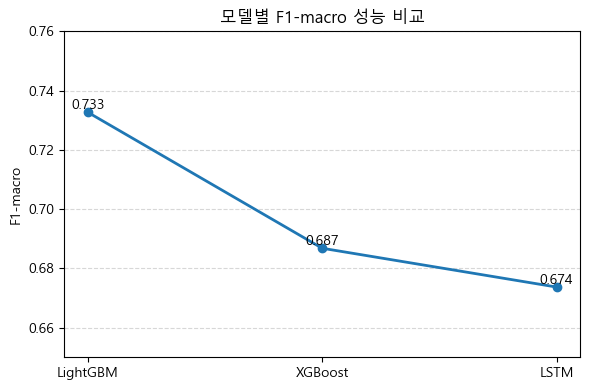

In [3]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 데이터
models = ["LightGBM", "XGBoost", "LSTM"]
f1_macro = [0.7327, 0.6868, 0.6737]

# 선 그래프
plt.figure(figsize=(6, 4))
plt.plot(models, f1_macro, marker="o", linewidth=2)

# 값 표시
for x, y in zip(models, f1_macro):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom")

plt.ylim(0.65, 0.76)
plt.ylabel("F1-macro")
plt.title("모델별 F1-macro 성능 비교")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


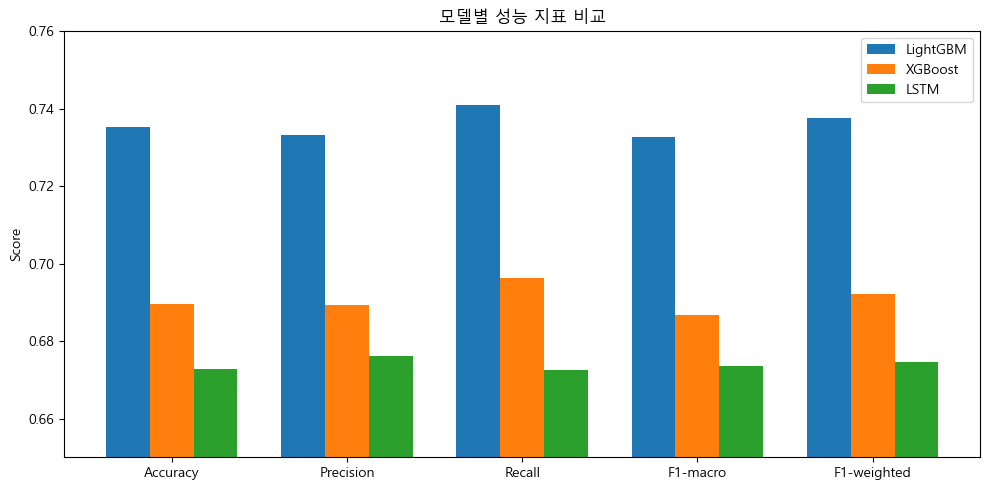

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 데이터
models = ["LightGBM", "XGBoost", "LSTM"]
metrics = ["Accuracy", "Precision", "Recall", "F1-macro", "F1-weighted"]

values = [
    [0.7353, 0.7333, 0.7409, 0.7327, 0.7376],  # LightGBM
    [0.6896, 0.6894, 0.6963, 0.6868, 0.6921],  # XGBoost
    [0.6728, 0.6762, 0.6725, 0.6737, 0.6747],  # LSTM
]

values = np.array(values)

# 시각화
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 5))
for i, model in enumerate(models):
    plt.bar(x + i * width, values[i], width, label=model)

plt.xticks(x + width, metrics)
plt.ylim(0.65, 0.76)
plt.ylabel("Score")
plt.title("모델별 성능 지표 비교")
plt.legend()
plt.tight_layout()
plt.show()
